# GP Regression with NumPyro + gaussx

This notebook shows how to use `gaussx.MultivariateNormal` inside a
NumPyro model for full Bayesian Gaussian process regression. Because
gaussx distributions accept **lineax operators** as covariances, we
get structured linear algebra (Cholesky, Woodbury, etc.) for free
while using NumPyro's MCMC and predictive machinery.

**What you'll learn:**

1. Defining a GP model with `gaussx.MultivariateNormal`
2. Inferring kernel hyperparameters via NUTS
3. Posterior predictive sampling with `numpyro.infer.Predictive`
4. Comparing against the analytic GP posterior

## Background

In standard GP regression, hyperparameters $\theta$ (kernel variance,
lengthscale, noise) are set by maximizing the log-marginal likelihood
-- a point estimate (type-II ML). Full Bayesian treatment places priors
on $\theta$ and integrates them out:

$$p(f_* | y) = \int p(f_* | y, \theta)\, p(\theta | y)\, d\theta$$

This integral is intractable, but MCMC (here NUTS; Hoffman & Gelman,
2014) samples from $p(\theta | y)$ and averages the GP predictive over
those samples. The result is better-calibrated uncertainty that accounts
for hyperparameter uncertainty -- important when data is scarce or
hyperparameters are poorly identified.

## Setup

In [1]:
from __future__ import annotations

import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

import gaussx


jax.config.update("jax_enable_x64", True)

## Generate data

We sample from a smooth function with additive Gaussian noise.

In [2]:
key = jax.random.PRNGKey(42)
n_train = 30
noise_std = 0.2

f_true = lambda x: jnp.sin(2 * x) * jnp.exp(-0.3 * x)

key, subkey = jax.random.split(key)
X_train = jnp.sort(jax.random.uniform(subkey, (n_train,), minval=-2, maxval=5))
key, subkey = jax.random.split(key)
y_train = f_true(X_train) + noise_std * jax.random.normal(subkey, (n_train,))

X_test = jnp.linspace(-2.5, 5.5, 200)

print(f"Training points: {n_train}")
print(f"Test points:     {len(X_test)}")

Training points: 30
Test points:     200


## Define the NumPyro model

We place log-normal priors on the RBF kernel hyperparameters
(variance, lengthscale) and a half-normal prior on the observation
noise. The likelihood uses `gaussx.MultivariateNormal` with a
lineax PSD operator.

In [3]:
def gp_model(X, y=None):
    # Priors on kernel hyperparameters
    var = numpyro.sample("kernel_var", dist.LogNormal(0.0, 1.0))
    length = numpyro.sample("kernel_length", dist.LogNormal(0.0, 1.0))
    noise = numpyro.sample("noise", dist.HalfNormal(0.5))

    # RBF kernel matrix
    diff = X[:, None] - X[None, :]
    K = var * jnp.exp(-0.5 * diff**2 / length**2) + noise**2 * jnp.eye(len(X))

    # Wrap as lineax PSD operator
    K_op = lx.MatrixLinearOperator(K, lx.positive_semidefinite_tag)

    # Likelihood via gaussx
    numpyro.sample("obs", gaussx.MultivariateNormal(jnp.zeros(len(X)), K_op), obs=y)

## Run NUTS

We use NumPyro's NUTS sampler to infer the kernel hyperparameters.
The `gaussx.MultivariateNormal.log_prob` is fully differentiable
via JAX, so NUTS can compute gradients through the structured
linear algebra.

In [4]:
kernel = NUTS(gp_model)
mcmc = MCMC(kernel, num_warmup=300, num_samples=500, progress_bar=False)
mcmc.run(jax.random.PRNGKey(0), X_train, y=y_train)
mcmc.print_summary()


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
  kernel_length      0.74      0.23      0.70      0.38      1.07    130.19      1.00
     kernel_var      0.75      0.83      0.47      0.12      1.59     83.70      1.01
          noise      0.20      0.04      0.19      0.14      0.26    288.93      1.00

Number of divergences: 0


In [5]:
samples = mcmc.get_samples()
print("Posterior shapes:")
for k, v in samples.items():
    print(f"  {k}: {v.shape}")

Posterior shapes:
  kernel_length: (500,)
  kernel_var: (500,)
  noise: (500,)


## Posterior hyperparameter distributions

The MCMC samples give us full posteriors over the kernel
hyperparameters. Let's visualize them.

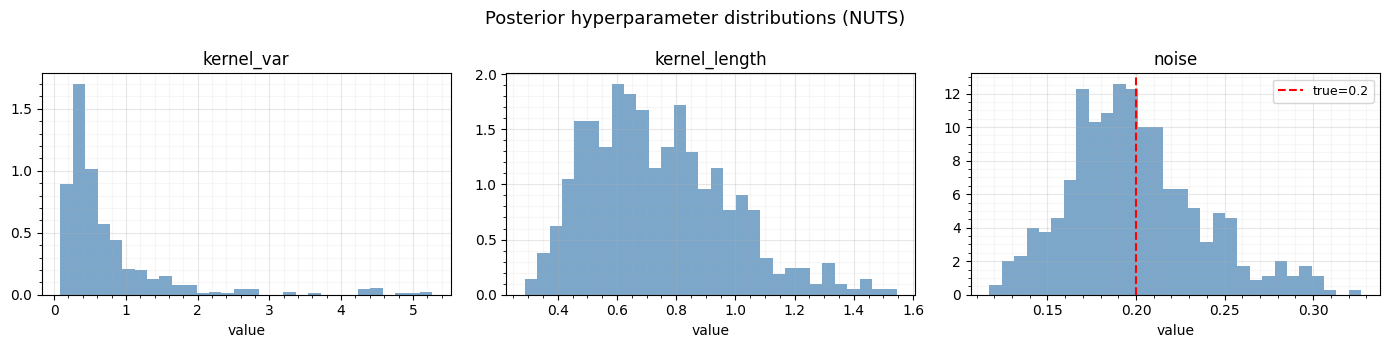

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

for ax, name, true_val in zip(
    axes,
    ["kernel_var", "kernel_length", "noise"],
    [None, None, noise_std],
    strict=True,
):
    ax.hist(samples[name], bins=30, density=True, alpha=0.7, color="steelblue")
    ax.set_title(name)
    ax.set_xlabel("value")
    if true_val is not None:
        ax.axvline(true_val, color="red", ls="--", label=f"true={true_val}")
        ax.legend(fontsize=9)
    ax.grid(True, which="major", alpha=0.3)
    ax.grid(True, which="minor", alpha=0.1)
    ax.minorticks_on()

fig.suptitle("Posterior hyperparameter distributions (NUTS)", fontsize=13)
plt.tight_layout()
plt.show()

## Posterior predictive

For each posterior sample of hyperparameters, we compute the
analytic GP predictive mean and variance at test locations.

The total predictive variance decomposes via the law of total variance:

$$
\operatorname{Var}[y_* | \mathcal{D}]
= \underbrace{\mathbb{E}_\theta[\operatorname{Var}
  [y_* | \theta, \mathcal{D}]]}_{\text{aleatoric}}
+ \underbrace{\operatorname{Var}_\theta[\mathbb{E}
  [y_* | \theta, \mathcal{D}]]}_{\text{hyper. unc.}}
$$

In [7]:
def gp_predict(X_train, y_train, X_test, var, length, noise):
    """Analytic GP posterior mean and variance at test points."""
    # Training kernel
    diff_tr = X_train[:, None] - X_train[None, :]
    K_tr = var * jnp.exp(-0.5 * diff_tr**2 / length**2)
    K_tr += noise**2 * jnp.eye(len(X_train))

    # Cross kernel
    diff_ts = X_test[:, None] - X_train[None, :]
    K_ts = var * jnp.exp(-0.5 * diff_ts**2 / length**2)

    # Test kernel diagonal
    K_tt_diag = var * jnp.ones(len(X_test))

    # Solve via gaussx (vector solves, vmapped over test columns)
    K_tr_op = lx.MatrixLinearOperator(K_tr, lx.positive_semidefinite_tag)
    alpha = gaussx.solve(K_tr_op, y_train)

    # Predictive mean and variance
    mu = K_ts @ alpha
    # gaussx.solve is a vector solver; vmap over columns for matrix RHS
    solve_col = lambda col: gaussx.solve(K_tr_op, col)
    v = jax.vmap(solve_col, in_axes=1, out_axes=1)(K_ts.T)  # (n_train, n_test)
    var_pred = K_tt_diag - jnp.sum(K_ts * v.T, axis=1)
    return mu, var_pred


# Predict for each posterior sample
predict_fn = jax.vmap(
    lambda var, length, noise: gp_predict(X_train, y_train, X_test, var, length, noise)
)

mus, vars_ = predict_fn(
    samples["kernel_var"], samples["kernel_length"], samples["noise"]
)

mu_mean = jnp.mean(mus, axis=0)
mu_std = jnp.std(mus, axis=0)

# Law of total variance:
#   Var(y*|D) = E_θ[Var(y*|θ,D)] + Var_θ(E[y*|θ,D])
# vars_ is latent function variance; add observation noise per sample
noise_vars = samples["noise"] ** 2  # (num_samples,)
aleatoric_var = jnp.mean(vars_ + noise_vars[:, None], axis=0)
total_var = mu_std**2 + aleatoric_var
total_var = jnp.clip(total_var, a_min=0.0)  # guard against roundoff
total_std = jnp.sqrt(total_var)

print(f"Predictive mean shape: {mu_mean.shape}")
print(f"Total std shape:       {total_std.shape}")

Predictive mean shape: (200,)
Total std shape:       (200,)


## Plot predictions

The shaded bands show $\pm 2\sigma$ total predictive uncertainty,
combining both hyperparameter uncertainty (from MCMC) and
observation noise.

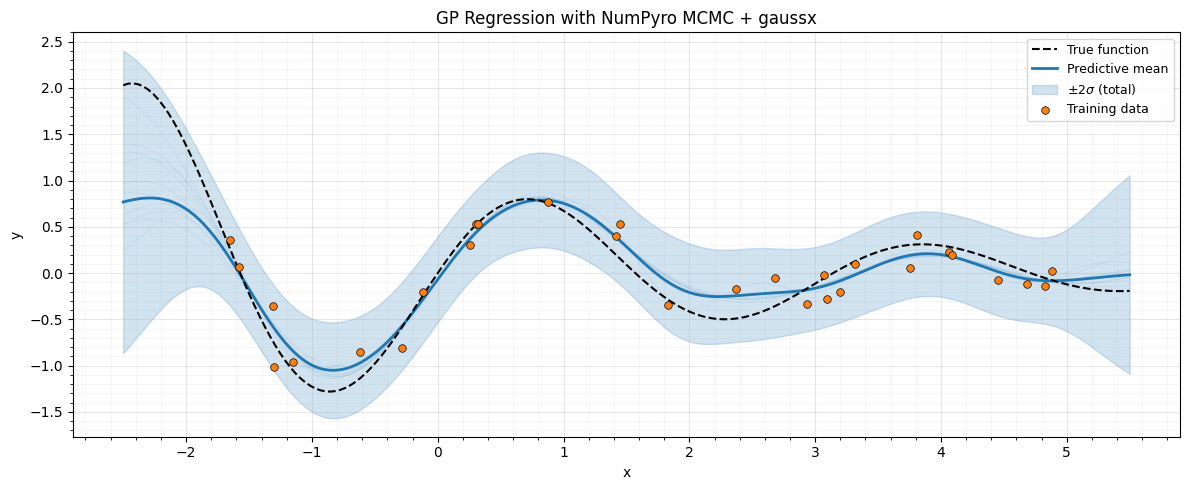

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

# True function
ax.plot(X_test, f_true(X_test), "k--", lw=1.5, label="True function", zorder=4)

# Predictive mean and uncertainty
ax.plot(X_test, mu_mean, "C0-", lw=2, label="Predictive mean", zorder=3)
ax.fill_between(
    X_test,
    mu_mean - 2 * total_std,
    mu_mean + 2 * total_std,
    color="C0",
    alpha=0.2,
    label=r"$\pm 2\sigma$ (total)",
)

# A few posterior function draws
for i in range(10):
    ax.plot(X_test, mus[i * 50], "C0-", alpha=0.1, lw=0.5)

# Training data
ax.scatter(
    X_train,
    y_train,
    s=30,
    c="C1",
    edgecolors="k",
    linewidths=0.5,
    label="Training data",
    zorder=5,
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("GP Regression with NumPyro MCMC + gaussx")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()
plt.tight_layout()
plt.show()

## Summary

- `gaussx.MultivariateNormal` plugs directly into NumPyro models,
  enabling NUTS inference over GP hyperparameters.
- The distribution's `log_prob` uses gaussx structural dispatch
  (Cholesky for PSD operators), and is fully differentiable for
  gradient-based sampling.
- Posterior predictive predictions combine hyperparameter
  uncertainty (from MCMC) with observation noise for calibrated
  uncertainty estimates.
- The same pattern works with structured covariances (Kronecker,
  BlockDiag, LowRankUpdate) for scalable GP models.

## References

- Hoffman, M. D. & Gelman, A. (2014). The No-U-Turn Sampler. *JMLR*,
  15, 1593--1623.
- Rasmussen, C. E. & Williams, C. K. I. (2006). *Gaussian Processes
  for Machine Learning*. MIT Press. (Section 5.2 on Bayesian
  hyperparameter treatment)
- Phan, D., Pradhan, N., & Jankowiak, M. (2019). Composable effects
  for flexible and accelerated probabilistic programming in NumPyro.
  *arXiv:1912.11554*.